# 이미지와 넘파이

- 이미지는 배열로 표현 가능 (Numpy)


## 이미지 읽기 1

- `pillow`, `matplotlib`와 `OpenCV` 모두 가능

- 구글 코랩(Colab), 쥬피터 노트북과 같은 환경에서는 pillow(PIL), matplotlib이 더 적합

- OpenCV는 주로 파이썬 스크립트 환경에서 사용
  - colab 에서는 `from google.colab.patches import cv2_imshow`으로  
    이미지는 출력할 수는 있지만 동영상 관련 처리는 불가

In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
# plt.style.use('seaborn-white')

from PIL import Image
import requests
from io import BytesIO  # binary 파일 입출력


In [2]:
base_path = r'/Users/leo/LeoData/MyCode/KoreaITAcademy/LangChain/dataset/ComputerVision/01'

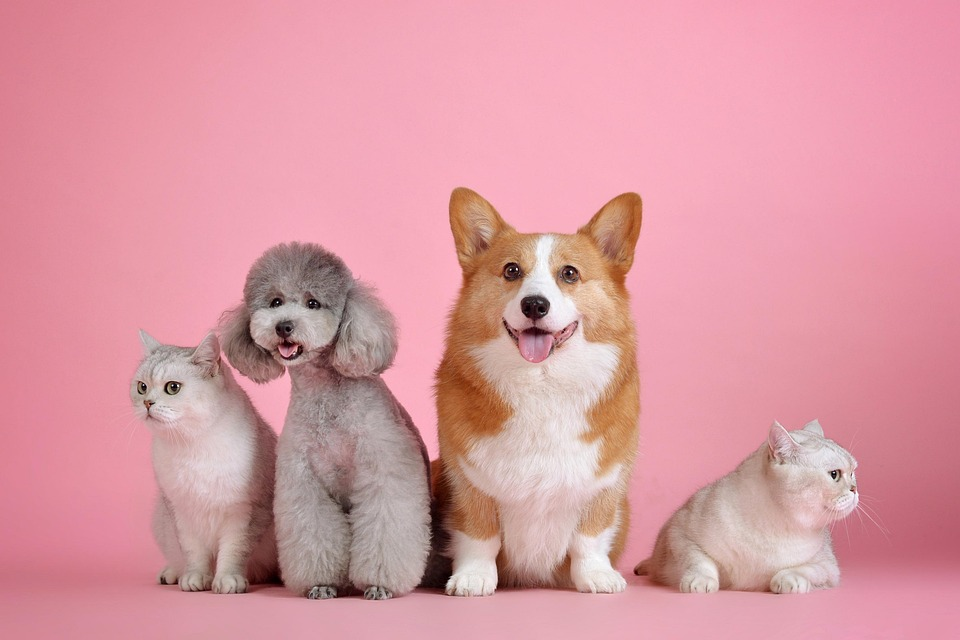

In [3]:
# url 과 Image객체 활용하여 이미지 읽기

url = 'https://cdn.pixabay.com/photo/2018/10/01/09/21/pets-3715733_960_720.jpg'
response = requests.get(url)
pic = Image.open(BytesIO(response.content))

pic  # 이미지 확인 (Pillow Image 객체)

In [4]:
type(pic)

PIL.JpegImagePlugin.JpegImageFile

In [5]:
# PIL 이미지 -> numpy 변환
pic_arr = np.array(pic)

pic_arr.shape

(640, 960, 3)

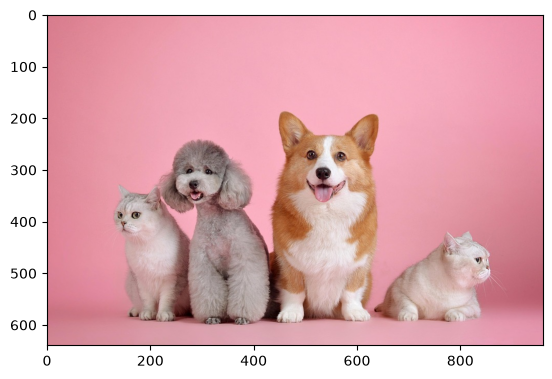

In [6]:
# numpy 출력
plt.imshow(pic_arr)
plt.show()

In [7]:
pic_copy = pic_arr.copy()

In [8]:
# 채널 순서 (R, G, B)

pic_copy[:, :, 0]  # Red 채널


array([[215, 215, 216, ..., 231, 232, 233],
       [214, 214, 215, ..., 232, 232, 234],
       [214, 215, 215, ..., 234, 234, 235],
       ...,
       [211, 211, 211, ..., 230, 230, 231],
       [212, 211, 211, ..., 231, 231, 231],
       [212, 212, 211, ..., 231, 231, 232]], shape=(640, 960), dtype=uint8)

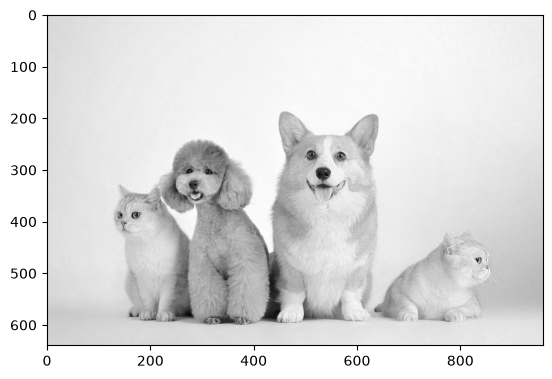

In [9]:
plt.imshow(pic_copy[:, :, 0], cmap='gray')
plt.show()

In [10]:
pic_copy[..., 1]  # Green Channel

array([[124, 124, 125, ..., 143, 144, 145],
       [123, 123, 124, ..., 144, 144, 146],
       [123, 124, 124, ..., 144, 144, 145],
       ...,
       [133, 133, 133, ..., 150, 150, 151],
       [134, 133, 133, ..., 151, 151, 151],
       [134, 134, 133, ..., 151, 151, 152]], shape=(640, 960), dtype=uint8)

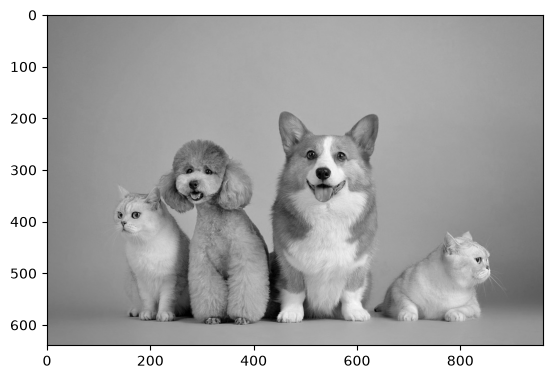

In [11]:
plt.imshow(pic_copy[..., 1], cmap='gray')
plt.show()

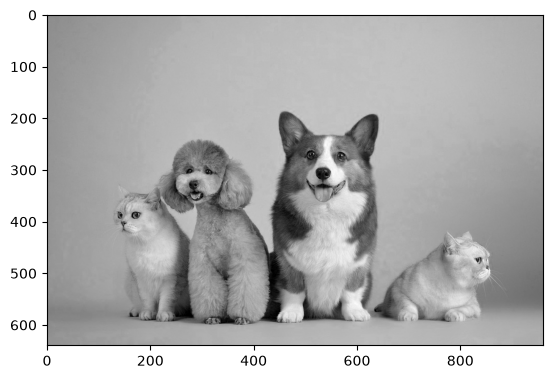

In [12]:
plt.imshow(pic_copy[..., 2], cmap='gray')  # Blue 채널
plt.show()

In [13]:
# Red 채널 분포 확인

pic_red = pic_arr.copy()
# G, B 을 0으로 바꿈
pic_red[:, :, 1] = 0
pic_red[:, :, 2] = 0

pic_red

array([[[215,   0,   0],
        [215,   0,   0],
        [216,   0,   0],
        ...,
        [231,   0,   0],
        [232,   0,   0],
        [233,   0,   0]],

       [[214,   0,   0],
        [214,   0,   0],
        [215,   0,   0],
        ...,
        [232,   0,   0],
        [232,   0,   0],
        [234,   0,   0]],

       [[214,   0,   0],
        [215,   0,   0],
        [215,   0,   0],
        ...,
        [234,   0,   0],
        [234,   0,   0],
        [235,   0,   0]],

       ...,

       [[211,   0,   0],
        [211,   0,   0],
        [211,   0,   0],
        ...,
        [230,   0,   0],
        [230,   0,   0],
        [231,   0,   0]],

       [[212,   0,   0],
        [211,   0,   0],
        [211,   0,   0],
        ...,
        [231,   0,   0],
        [231,   0,   0],
        [231,   0,   0]],

       [[212,   0,   0],
        [212,   0,   0],
        [211,   0,   0],
        ...,
        [231,   0,   0],
        [231,   0,   0],
        [232,   0,   0]]

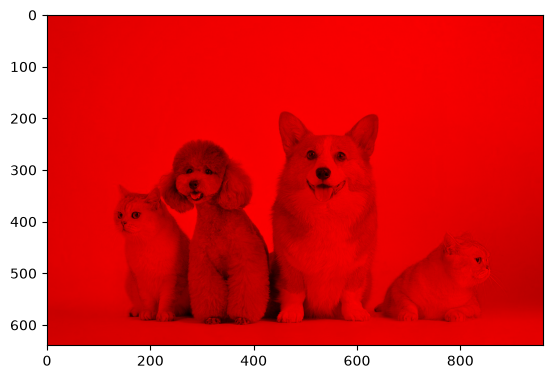

In [14]:
plt.imshow(pic_red)
plt.show()

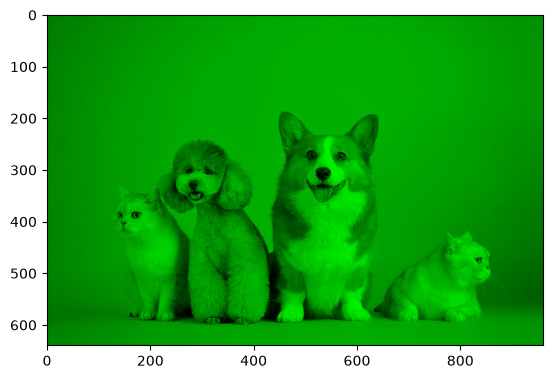

In [15]:
# Green 채널 분포 확인

pic_green = pic_arr.copy()
# G, B 을 0으로 바꿈
pic_green[:, :, 0] = 0
pic_green[:, :, 2] = 0

plt.imshow(pic_green)
plt.show()

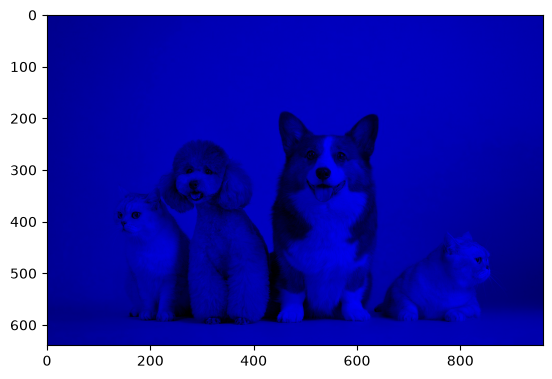

In [16]:
# Blue 채널 분포 확인

pic_blue = pic_arr.copy()
# G, B 을 0으로 바꿈
pic_blue[:, :, 0] = 0
pic_blue[:, :, 1] = 0

plt.imshow(pic_blue)
plt.show()

In [17]:
def cv2_imshow(image):
    cv2.imshow('image', image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    for _ in range(5):
        cv2.waitKey(1)

In [18]:
cv2_imshow(pic_arr)

## OpenCV 의 채널 순서
- OpenCV를 통해 영상(이미지)을 다룰 때의 채널 순서는 B G R
- matplotlib은 R G B 순서

- `cv2.cvtColor()`
  
  - image arrary, 변경할 색공간을 인자로 넣어줌 

  - 변경할 색공간은 여러 가지가 있음
    - `cv2.COLOR_BGR2RGB`

    - `cv2.COLOR_RGB2GRAY`

    - `cv2.COLOR_GRAY2RGB`

    - ...


In [19]:
image = cv2.cvtColor(pic_arr, cv2.COLOR_RGB2BGR)
cv2_imshow(image)

In [20]:
# 비교
image[0][0]

array([142, 124, 215], dtype=uint8)

In [21]:
pic_arr[0, 0]

array([215, 124, 142], dtype=uint8)

In [22]:
# channel 인덱스 순서 변경하기
temp_arr = pic_arr[:, :, ::-1]
cv2_imshow(temp_arr)

## 이미지 읽기 2
- `cv2.imread()`

  - path, 이미지 파일의 flag값을 인자로 넣어줌

    - `cv2.IMREAD_COLOR`  
      이미지 파일을 Color로 읽어들이고, 투명한 부분은 무시되며, Default 값
    
    - `cv2.IMREAD_GRAYSCALE`  
      이미지를 Grayscale로 읽음. 실제 이미지 처리시 중간단계로 많이 사용
    
    - `cv2.IMREAD_UNCHANGED`  
      이미지 파일을 alpha channel (투명도)까지 포함하여 읽어 들임

- **(주의)**
  - `cv2.imread()`는 잘못된 경로로 읽어도 `NoneType`으로 들어갈 뿐, <u>오류를 발생하지 않음</u>


In [23]:
image = cv2.imread(os.path.join(base_path, 'Lenna.png'), cv2.IMREAD_UNCHANGED)
print(image.shape)
cv2_imshow(image)

(512, 512, 3)


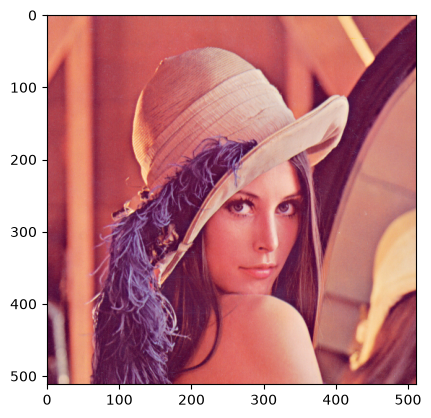

In [24]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.show()

# 컬러 매핑(Color Mapping)

- 주로 그레이 스케일(Grayscale), 트루 컬러(True Color, RGB)이미지를 많이 활용

- 다양한 색 공간(ex, `HSV`, `YCrCB` 등)이 존재하고 이들을 변환할 수 있음
  
- 컬러 영상 처리에서 `HSV`와 `HSL`은 같은 색 공간을 이용하여 색상 구분에 용이하고, `YCrCb`와 `YUV`는 휘도 성분 구분에 용이

- `cv2.cvtColor()` 활용


## 색 공간의 종류 (참고)

- RGB
  - 컬러 표현을 빛의 3원색인 (Red, Green, Blue)으로 서로 다른 비율을 통해 색 표현

- CMYK
  - Cyan, Magenta, Yellow, Black를 기본으로 하여 주로 컬러 프린터나 인쇄시에 사용

  - 각 성분들의 감산에 의해 컬러 구현

- YUV

  - Y축은 밝기 성분을 U,V 두축을 이용하여 색상을 표현
  
  - U축은 파란색에서 밝기 성분을 뺀 값, V축은 빨간색에서 밝기 성분을 뺀 값
    
  - 아날로그 컬러신호 변환에 주로 사용.  (U = B - Y) , (V = R - Y)

- YCbCr
  
  - Digital TV에서 사용하는 색공간
  
  - YPbPr이라는 아날로그 신호의 색공간을 디지털화한 것
  
  - YPbPr은 아날로그 컴포넌트 비디오에서 사용



In [40]:
origin_img = cv2.imread(os.path.join(base_path, 'dog1.jpg'))
print(origin_img.shape)
cv2_imshow(origin_img)

(427, 640, 3)


## HSV Color Space

- 색상(Hue), 채도(Saturation), 명도(Value)로 색을 표현

- 색상은 흔히 빨간색, 노란색 등과 같은 색의 종류

- 채도는 색의 순도  

  예들 들어, 파란색에서 
  
  - 채도가 높으면 맑고 선한 파란색

  - 채도가 낮으면 탁한 파란색

- 명도는 빛의 세기

  - 명도가 높으면 밝고, 낮으면 어둡게 느껴진다.

- OpenCV에서 `BGR2HSV` 색 공간 변환할 경우,  
  - `H` : 0 ~ 179 사이의 정수로 표현
    - 색상 값은 0° ~ 360° 로 표현하지만  
      uchar 자료형은 256이상의 정수를 표현할 수 없기 때문에 OpenCV에서는 각도를 2로 나눈 값을 H로 저장

  - `S` : 0 ~ 255 사이의 정수로 표현

  - `V` : 0 ~ 255 사이의 정수로 표현

- 사람이 실제로 색을 인지하는 방식

  <br>

  <img src="https://upload.wikimedia.org/wikipedia/commons/f/f1/HSV_cone.jpg?utm_source=ko.wikipedia.org&utm_campaign=index&utm_content=original">

  <sub>[이미지 출처] https://ko.wikipedia.org/wiki/HSV_%EC%83%89_%EA%B3%B5%EA%B0%84</sub>


In [26]:
img_hsv = cv2.cvtColor(origin_img, cv2.COLOR_BGR2HSV)
img_hsv  # [H, S, V]
# H는 0 ~ 179 값
# S, V는 0 ~ 255값

array([[[125,   7, 219],
        [125,   7, 219],
        [125,   7, 219],
        ...,
        [ 16,  32, 206],
        [ 16,  32, 206],
        [ 16,  32, 206]],

       [[125,   7, 218],
        [125,   7, 218],
        [125,   7, 218],
        ...,
        [ 16,  32, 206],
        [ 16,  32, 206],
        [ 16,  32, 207]],

       [[125,   7, 218],
        [125,   7, 218],
        [125,   7, 218],
        ...,
        [ 16,  32, 206],
        [ 16,  32, 206],
        [ 16,  32, 207]],

       ...,

       [[ 11,  20, 212],
        [ 11,  20, 212],
        [ 11,  21, 211],
        ...,
        [ 14,  15, 216],
        [ 14,  15, 216],
        [ 14,  15, 216]],

       [[ 11,  21, 211],
        [ 11,  21, 211],
        [ 11,  21, 211],
        ...,
        [ 14,  15, 214],
        [ 14,  15, 214],
        [ 14,  15, 214]],

       [[ 11,  25, 213],
        [ 11,  25, 213],
        [  9,  23, 213],
        ...,
        [ 14,  16, 213],
        [ 14,  16, 212],
        [ 14,  16, 212]]

In [27]:
# H값: 0 ~ 179 값 (360도 각도를 2로 나눈 값)
np.max(img_hsv[:, 0, 0]), np.min(img_hsv[:, 0, 0])

(np.uint8(177), np.uint8(0))

## YCrCb Color Space

- Y 성분은 밝기 또는 휘도(luminance), Cr, Cb 성분은 색상 또는 색차(chrominance)를 나타냄

- Cr, Cb는 오직 색상 정보만 가지고 있음. 밝기 정보 X

- 영상을 GrayScale 정보와 색상 정보로 분리하여 처리할 때 유용

- `Y`, `Cr`, `Cb`  : 0 ~ 255 사이의 정수로 표현

  <br>

  <!-- <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/3/34/YCbCr-CbCr_Scaled_Y50.png/600px-YCbCr-CbCr_Scaled_Y50.png" width="300"> -->
  <img src="https://upload.wikimedia.org/wikipedia/commons/b/b8/YCbCr.GIF">

  <sub>[이미지 출처] https://en.wikipedia.org/wiki/YCbCr</sub>


In [28]:
img_ycrcb = cv2.cvtColor(origin_img, cv2.COLOR_BGR2YCrCb)
print(img_ycrcb.shape)
img_ycrcb

(427, 640, 3)


array([[[214, 128, 131],
        [214, 128, 131],
        [214, 128, 131],
        ...,
        [196, 135, 119],
        [196, 135, 119],
        [196, 135, 119]],

       [[213, 128, 131],
        [213, 128, 131],
        [213, 128, 131],
        ...,
        [196, 135, 119],
        [196, 135, 119],
        [197, 135, 119]],

       [[213, 128, 131],
        [213, 128, 131],
        [213, 128, 131],
        ...,
        [196, 135, 119],
        [196, 135, 119],
        [197, 135, 119]],

       ...,

       [[204, 134, 123],
        [204, 134, 123],
        [203, 134, 123],
        ...,
        [210, 132, 124],
        [210, 132, 124],
        [210, 132, 124]],

       [[203, 134, 123],
        [203, 134, 123],
        [203, 134, 123],
        ...,
        [208, 132, 124],
        [208, 132, 124],
        [208, 132, 124]],

       [[203, 135, 122],
        [203, 135, 122],
        [203, 135, 123],
        ...,
        [207, 132, 124],
        [206, 132, 124],
        [206, 132, 124]]

# 도형 그리기

- 다양한 도형을 그릴 수 있음

- 도형을 그리는 좌표가 해당 범위를 넘어가면 이미지에 표현되지 않음


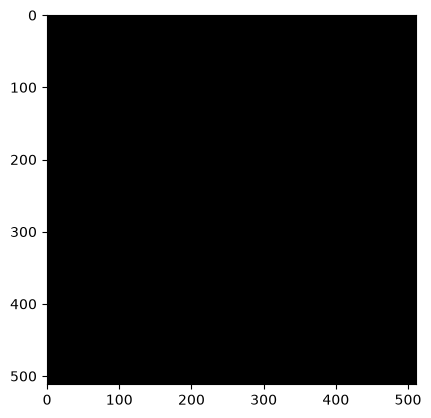

In [29]:
# 0으로 채워진 이미지 하나 만들자
img = np.zeros((512, 512, 3), np.uint8)

plt.imshow(img)
plt.show()

## Line 그리기

- `cv.line()`

  - `Parameters`  	
    - `img` : 그림을 그릴 이미지 파일

    - `start` : 시작 좌표

    - `end` : 종료 좌표

    - `color` : BGR형태의 Color (ex; (255, 0, 0) -> Blue)

    - `thickness` (int) : 선의 두께. pixel
    <br>
- ★리턴값은 적용된 이미지 데이터, 그러나 `img` 원본도 변화된다!!!!!   ★


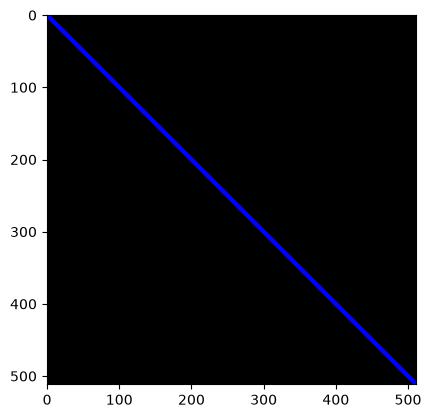

In [30]:
cv2.line(img, (0, 0), (511, 511), (255, 0, 0), 5)

plt.imshow(img[:, :, ::-1])
plt.show()

## rectangle 그리기

- `cv2.rectangle()`

  - `Parameters`  	
    - `img` : 그림을 그릴 이미지

    - `start` : 시작 좌표

    - `end` : 종료 좌표

    - `color` : BGR형태의 Color(ex; (255, 0, 0) -> Blue)

    - `thickness` (int) : 선의 두께. pixel



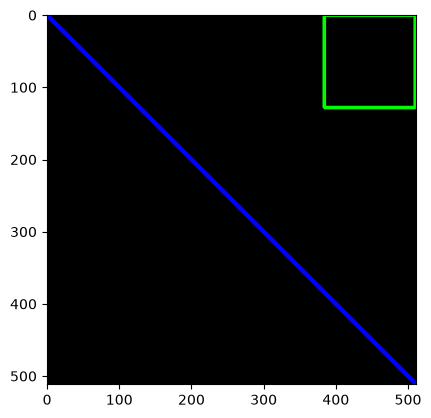

In [31]:
cv2.rectangle(img, (384, 0), (510, 128), (0, 255, 0), 3)

plt.imshow(img[..., ::-1])
plt.show()

## Circle 그리기

- `cv2.circle()`

  - `Parameters`  	
    - `img` : 그림을 그릴 이미지

    - `center` : 원의 중심 좌표(x, y)

    - `radius` : 반지름

    - `color` : BGR형태의 Color

    - `thickness` : 선의 두께, -1 이면 원 안쪽을 채움

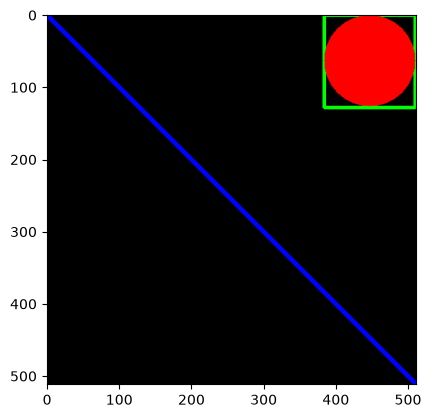

In [32]:
cv2.circle(img, (447, 63), 63, (0, 0, 255), -1)
plt.imshow(img[..., ::-1])
plt.show()

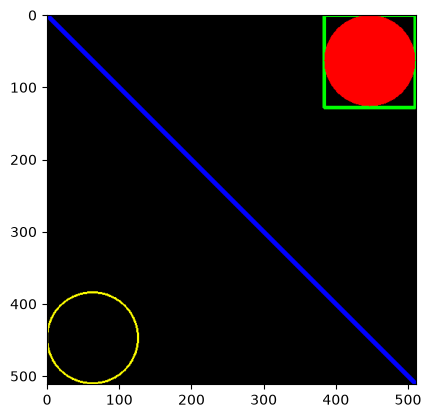

In [33]:
cv2.circle(img, (63, 447), 63, (0, 255, 255), 2)
plt.imshow(img[..., ::-1])
plt.show()

## ellipse(타원) 그리기

- `cv2.ellipse()`

  - `Parameters`  
    
    - `img` : image

    - `center` : 타원의 중심

    - `axes` : 중심에서 가장 큰 거리와 작은 거리

    - `angle` : 타원의 기울기 각

    - `startAngle` : 타원의 시작 각도

    - `endAngle` : 타원이 끝나는 각도

    - `color` : 타원의 색

    - `thickness` : 선 두께. -1이면 안쪽을 채움


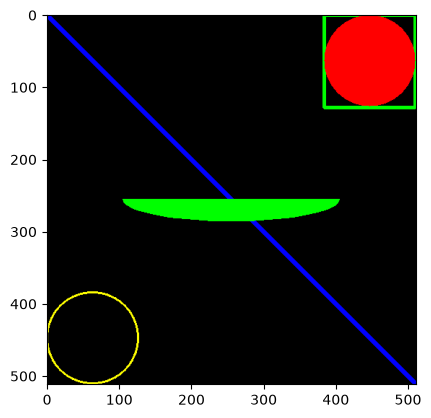

In [34]:
cv2.ellipse(img, (255, 255), (150, 30), 0, 0, 180, (0, 255, 0), -1)

plt.imshow(img[..., ::-1])
plt.show()

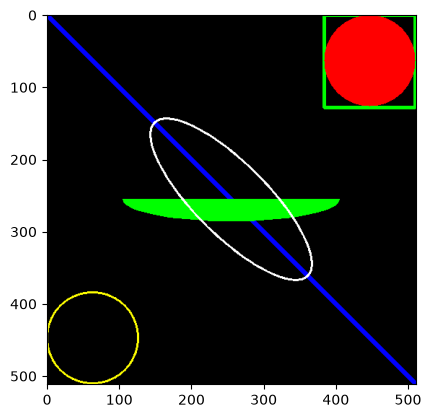

In [35]:
cv2.ellipse(img, (255, 255), (150, 50), 45, 0, 360, (255, 255, 255), 2)

plt.imshow(img[..., ::-1])
plt.show()

## Polygon 그리기

- `cv2.polylines()`
  
  - `Parameters`	
    
    - `img` : image

    - `pts` (array) : 연결할 꼭지점 좌표들 (3차원 형태 ※아래 참조)

    - `isClosed` : 닫힌 도형 여부

    - `color` : Color

    - `thickness` : 선 두께

- 여러 polyline을 한 번에 처리하기 위해, 좌표를 3차원 행렬로 변환하여 전달해주어야 한다.

  - (polyline 의 개수, 각 polyline 을 이루는 점의 개수, 각 점의 좌표값 개수 ) 


In [36]:
# 하나의 polyline
# 4개의 꼭짓점
pts = np.array([[10, 5], [20, 30], [70, 20], [50, 10]], np.int32)
pts.shape


(4, 2)

In [37]:
# 이미지에 그리려면 3차원으로 준비해야 한다.
pts = pts.reshape(-1, 4, 2)
pts.shape

(1, 4, 2)

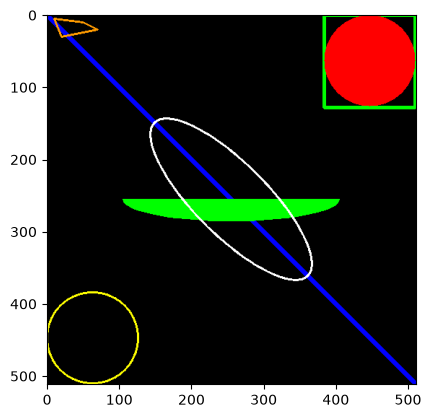

In [38]:
cv2.polylines(img, pts, True, (0, 155, 255), 2)

plt.imshow(img[..., ::-1])
plt.show()

In [42]:
pts2 = np.array([[150, 5], [200, 30], [100, 70], [50, 20]], np.int32)
pts2 = pts2.reshape(-1, 2, 1)

pts2.shape

(4, 2, 1)

In [43]:
# cv2.polylines(img, pts2, True, (172, 200, 255), 4)
# plt.imshow(img[..., ::-1])
# plt.show()

error: OpenCV(5.0.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/imgproc/src/drawing.cpp:2153: error: (-215:Assertion failed) p.checkVector(2, CV_32S) >= 0 in function 'polylines'


In [44]:
pts2 = pts2.reshape(-1, 4, 2)
pts2.shape

(1, 4, 2)

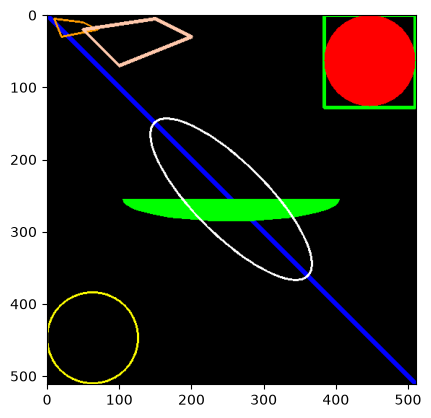

In [45]:
cv2.polylines(img, pts2, True, (172, 200, 255), 4)
plt.imshow(img[..., ::-1])
plt.show()